In [53]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [54]:

df = pd.read_csv("/kaggle/input/datasets/manshusehgal/sales-dataset-for-clustering/final_retail_sales.csv")

df.head()
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2224 entries, 0 to 2223
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Transaction ID       2224 non-null   int64  
 1   Date                 2224 non-null   object 
 2   Customer ID          2224 non-null   object 
 3   Gender               2224 non-null   object 
 4   Age                  2224 non-null   int64  
 5   Product Category     2224 non-null   object 
 6   Quantity             2224 non-null   int64  
 7   Price per Unit       2224 non-null   int64  
 8   Total Amount         2224 non-null   int64  
 9   Discount_Percentage  2224 non-null   int64  
 10  Final_Paid_Amount    2224 non-null   float64
 11  Payment_Method       2224 non-null   object 
 12  Is_Event             2224 non-null   object 
dtypes: float64(1), int64(6), object(6)
memory usage: 226.0+ KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount,Discount_Percentage,Final_Paid_Amount
count,2224.000000,2224.000000,2224.000000,2224.000000,2224.000000,2224.000000,2224.000000
mean,1112.500000,41.445144,2.499101,285.840827,715.103417,4.885342,680.886151
std,642.157821,13.749597,1.123102,286.957591,850.375040,9.123035,819.370331
min,1.000000,18.000000,1.000000,25.000000,25.000000,0.000000,18.750000
25%,556.750000,29.000000,1.000000,50.000000,100.000000,0.000000,100.000000
50%,1112.500000,42.000000,3.000000,200.000000,400.000000,0.000000,312.000000
75%,1668.250000,54.000000,4.000000,500.000000,1000.000000,0.000000,1000.000000
max,2224.000000,64.000000,4.000000,1000.000000,4000.000000,25.000000,4000.000000


In [55]:
df.isnull().sum()
df.duplicated().sum()
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Discount_Percentage', 'Final_Paid_Amount', 'Payment_Method',
       'Is_Event'],
      dtype='object')

In [56]:
customer_df = df.groupby('Customer ID').agg({
    'Final_Paid_Amount': 'sum',
    'Transaction ID': 'count',
    'Discount_Percentage': 'mean',
    'Quantity': 'sum'
}).reset_index()

customer_df.columns = [
    'Customer_ID',
    'Total_Spending',
    'Purchase_Frequency',
    'Avg_Discount',
    'Total_Quantity'
]

In [57]:
customer_df.columns
customer_df.shape
customer_df.head()

,Customer_ID,Total_Spending,Purchase_Frequency,Avg_Discount,Total_Quantity
0,CUST001,150.0,1,0.00,3
1,CUST002,1000.0,1,0.00,2
2,CUST003,6522.5,4,6.25,12
3,CUST004,500.0,1,0.00,1
4,CUST005,700.0,2,0.00,4


In [58]:
X = customer_df[[
    'Total_Spending',
    'Purchase_Frequency',
    'Avg_Discount',
    'Total_Quantity'
]]

X.head()

,Total_Spending,Purchase_Frequency,Avg_Discount,Total_Quantity
0,150.0,1,0.00,3
1,1000.0,1,0.00,2
2,6522.5,4,6.25,12
3,500.0,1,0.00,1
4,700.0,2,0.00,4


In [59]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.92594427, -1.21682726, -0.71820644, -0.85693166],
       [-0.34904921, -1.21682726, -0.71820644, -1.19193231],
       [ 3.39907196,  1.76559249,  0.21251143,  2.15807418],
       ...,
       [-0.60186498, -0.22268734,  2.63237789, -0.52193101],
       [-0.97684678, -1.21682726,  3.00466504, -0.52193101],
       [-0.08435618,  0.77145258,  0.27455929,  0.48307094]],
      shape=(1000, 4))

In [60]:
inertia = []
k_values = range(1, 11)
for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

inertia

[3999.9999999999964,
 2362.9339042790098,
 1696.3564613935096,
 1387.4525939849127,
 1200.343325874278,
 1024.534147194501,
 866.0493164603148,
 786.9785691260713,
 730.0680311010412,
 671.5572000961613]

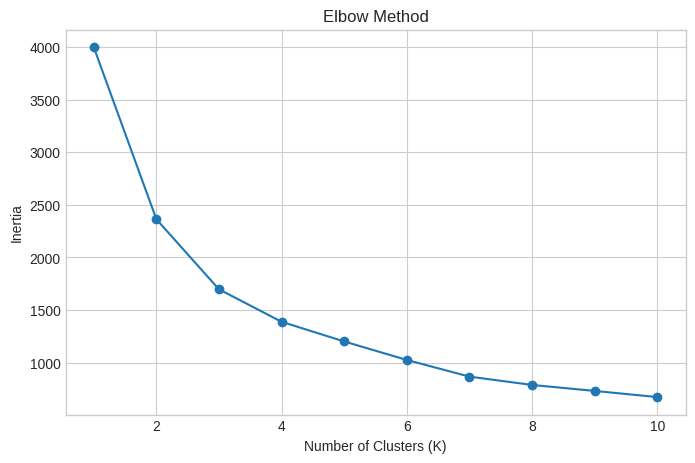

In [61]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title('Elbow Method')

plt.xlabel('Number of Clusters (K)')

plt.ylabel('Inertia')

plt.show()

In [62]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

In [63]:
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)
customer_df.head()

,Customer_ID,Total_Spending,Purchase_Frequency,Avg_Discount,Total_Quantity,Cluster
0,CUST001,150.0,1,0.00,3,2
1,CUST002,1000.0,1,0.00,2,2
2,CUST003,6522.5,4,6.25,12,1
3,CUST004,500.0,1,0.00,1,2
4,CUST005,700.0,2,0.00,4,2


In [64]:
customer_df['Cluster'].value_counts()

Cluster
2    380
3    324
0    206
1     90
Name: count, dtype: int64

In [65]:
kmeans.cluster_centers_

array([[-0.44644019, -0.34333539,  1.52358869, -0.41460071],
       [ 2.10818668,  1.6219945 , -0.04715196,  1.78957347],
       [-0.61458034, -0.77208045, -0.67901832, -0.75202356],
       [ 0.41904447,  0.67326592, -0.15922418,  0.64850336]])

In [66]:
cluster_summary = customer_df.groupby('Cluster')[[
    'Total_Spending',
    'Purchase_Frequency',
    'Avg_Discount'
]].mean()

cluster_summary

,Total_Spending,Purchase_Frequency,Avg_Discount
Cluster,,,
0,856.503641,1.878641,15.054207
1,4620.503333,3.855556,4.506296
2,608.765132,1.447368,0.263158
3,2131.712963,2.901235,3.753704


In [67]:
cluster_names = {
    0: 'Discount Hunters',
    1: 'Premium Customers',
    2: 'Low Engagement Customers',
    3: 'Regular Customers'
}

In [68]:
customer_df['Customer_Segment'] = customer_df['Cluster'].map(cluster_names)

customer_df.head()

,Customer_ID,Total_Spending,Purchase_Frequency,Avg_Discount,Total_Quantity,Cluster,Customer_Segment
0,CUST001,150.0,1,0.00,3,2,Low Engagement Customers
1,CUST002,1000.0,1,0.00,2,2,Low Engagement Customers
2,CUST003,6522.5,4,6.25,12,1,Premium Customers
3,CUST004,500.0,1,0.00,1,2,Low Engagement Customers
4,CUST005,700.0,2,0.00,4,2,Low Engagement Customers


In [69]:
customer_df['Customer_Segment'].value_counts()

Customer_Segment
Low Engagement Customers    380
Regular Customers           324
Discount Hunters            206
Premium Customers            90
Name: count, dtype: int64

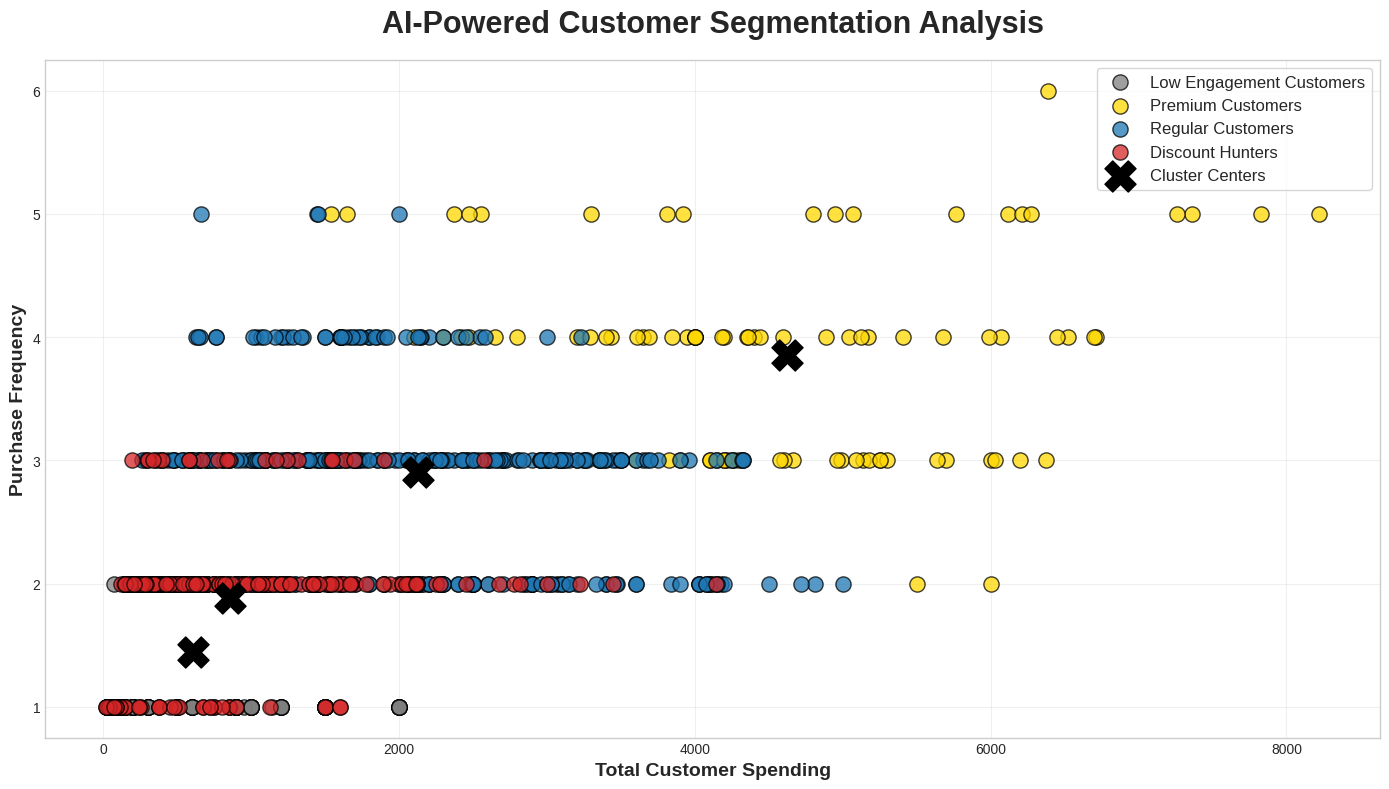

In [70]:
plt.style.use('seaborn-v0_8-whitegrid')

plt.figure(figsize=(14,8))

segment_colors = {
    'Premium Customers': '#FFD700',
    'Regular Customers': '#1f77b4',
    'Discount Hunters': '#d62728',
    'Low Engagement Customers': '#7f7f7f'
}

for segment in customer_df['Customer_Segment'].unique():

    subset = customer_df[
        customer_df['Customer_Segment'] == segment
    ]

    plt.scatter(
        subset['Total_Spending'],
        subset['Purchase_Frequency'],
        s=120,
        alpha=0.75,
        label=segment,
        color=segment_colors[segment],
        edgecolors='black'
    )

# Add Cluster Centroids
centroids = kmeans.cluster_centers_

centroids_original = scaler.inverse_transform(centroids)

plt.scatter(
    centroids_original[:,0],
    centroids_original[:,1],
    s=500,
    c='black',
    marker='X',
    label='Cluster Centers'
)

plt.title(
    'AI-Powered Customer Segmentation Analysis',
    fontsize=22,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Total Customer Spending',
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    'Purchase Frequency',
    fontsize=14,
    fontweight='bold'
)

plt.legend(
    fontsize=12,
    frameon=True
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

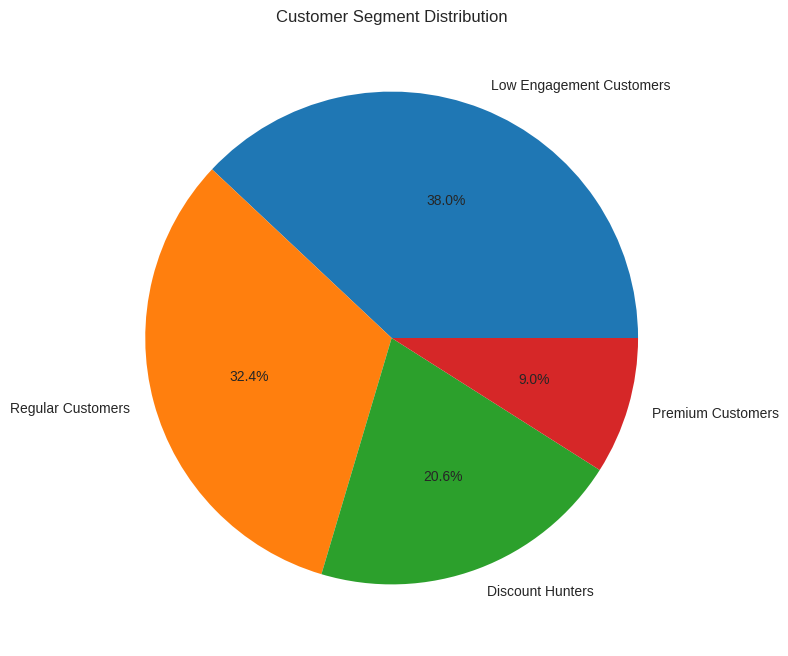

In [71]:
customer_df['Customer_Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title('Customer Segment Distribution')

plt.ylabel('')

plt.show()

In [72]:
# segment_colors = {
#     'Premium Customers': 'gold',
#     'Regular Customers': 'blue',
#     'Discount Hunters': 'red',
#     'Low Engagement Customers': 'gray'
# }

In [73]:
# plt.figure(figsize=(10,6))

# for segment in customer_df['Customer_Segment'].unique():
    
#     subset = customer_df[
#         customer_df['Customer_Segment'] == segment
#     ]
    
#     plt.scatter(
#         subset['Total_Spending'],
#         subset['Purchase_Frequency'],
#         label=segment,
#         color=segment_colors[segment]
#     )

# plt.xlabel('Total Spending')

# plt.ylabel('Purchase Frequency')

# plt.title('Customer Segments')

# plt.legend()

# plt.show()

In [74]:
customer_df.to_csv(
    'customer_segments.csv',
    index=False
)

In [75]:
business_summary = customer_df.groupby(
    'Customer_Segment'
)[[
    'Total_Spending',
    'Purchase_Frequency',
    'Avg_Discount'
]].mean()

business_summary

,Total_Spending,Purchase_Frequency,Avg_Discount
Customer_Segment,,,
Discount Hunters,856.503641,1.878641,15.054207
Low Engagement Customers,608.765132,1.447368,0.263158
Premium Customers,4620.503333,3.855556,4.506296
Regular Customers,2131.712963,2.901235,3.753704


In [76]:
segment_counts = customer_df[
    'Customer_Segment'
].value_counts()

segment_counts

Customer_Segment
Low Engagement Customers    380
Regular Customers           324
Discount Hunters            206
Premium Customers            90
Name: count, dtype: int64

In [77]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

sil_score = silhouette_score(X, clusters)

print("Silhouette Score:", sil_score)
print("Inertia:", kmeans.inertia_)

Silhouette Score: 0.6078591150633369
Inertia: 324333450.5662725


In [80]:
import pickle
with open('kmeans_model.pkl', 'wb') as file:
    pickle.dump(kmeans, file)